In [5]:
%load_ext autoreload
%autoreload 2

In [30]:
import argparse
import itertools
import pathlib
import sys

import os
from pathlib import Path

import sinter

import stim
import sinter
import pymatching
import numpy as np
import random
from typing import List, Callable, Tuple
import matplotlib.pyplot as plt
from dataclasses import dataclass



In [31]:
if '__file__' in globals():
    base_dir = Path(__file__).parent.parent
else:
    base_dir = Path.cwd().parent.parent

src_path = base_dir / 'magic-state-cultivation/src'
assert src_path.exists(), f"Src path {src_path} does not exist. Adjust the parent levels if the directory structure differs."
sys.path.append(str(src_path))

import cultiv
import gen
from cultiv._construction.full_clifford_sim.gap_sampler import *


In [32]:
print('\n'.join(f'{m.__name__}=={m.__version__}' for m in globals().values() if getattr(m, '__version__', None)))

argparse==1.1
sinter==1.15.0
stim==1.15.0
pymatching==2.3.1
numpy==2.2.6


## Creating fold transversal circuit 

In [33]:
folded_transversal_circuit_tasks =  [
    sinter.Task(
        circuit = cultiv.make_folded_transversal_circuit(
                p
            ),
        json_metadata={'p': p, 'b':'Y', 'noise':'uniform', 'd2':9, 
                        'c':f'e2e-Y-{"hookinj"}-g{3}-3ps1-stab{9}x{3}',
                        'ghz_size':3, 'latter_rounds': 3},
    )
    for p in [0.001, 0.002, 0.003]
]

folded_transversal_circuit_res = sinter.collect(tasks=folded_transversal_circuit_tasks,
            num_workers=4,
            decoders = ['pymatching-gap'],
            custom_decoders=sinter_samplers(),
                max_shots=10_000,  # Set a reasonable default
                max_errors=10_000 ,   # Set a reasonable default
                save_resume_filepath ="cultivation_outfile_results.csv"
        )
print(folded_transversal_circuit_res)

Shortest graphlike error length: 3
Shortest graphlike error length: 3
Shortest graphlike error length: 3
[sinter.TaskStats(strong_id='1abe422158270e58e1409aa059e03b4d1475b75d10eeb026883ce963dd34fcf8', decoder='pymatching-gap', json_metadata={'p': 0.003, 'b': 'Y', 'noise': 'uniform', 'd2': 9, 'c': 'e2e-Y-hookinj-g3-3ps1-stab9x3', 'ghz_size': 3, 'latter_rounds': 3}, shots=10000, errors=123, discards=7502, seconds=0.20118043292313814, custom_counts=Counter({'C58': 332, 'C26': 125, 'C25': 106, 'C36': 85, 'C42': 82, 'C16': 77, 'C37': 76, 'C18': 65, 'C35': 63, 'C43': 61, 'C39': 61, 'C38': 60, 'C41': 57, 'C17': 53, 'C33': 53, 'C21': 47, 'C34': 45, 'C19': 44, 'C44': 39, 'C15': 38, 'C46': 37, 'C24': 37, 'C40': 34, 'C31': 33, 'C13': 30, 'C5': 29, 'C14': 29, 'C27': 29, 'C28': 28, 'C23': 26, 'C55': 24, 'C7': 24, 'C20': 24, 'C9': 22, 'C22': 22, 'C4': 21, 'C32': 20, 'C54': 20, 'C45': 19, 'C12': 19, 'C49': 19, 'C51': 19, 'C29': 18, 'C10': 18, 'C57': 18, 'C30': 18, 'C8': 17, 'C56': 16, 'C6': 16, 'C11'

## Creating magic state cultivation (Gidney) circuit 

In [35]:
from cultiv._decoding._desaturation_sampler import DesaturationSampler
from cultiv._decoding._mux_sampler import sinter_samplers

In [36]:
def create_end2end_cultivation_tasks(noise_strength: float) -> sinter.Task:
    circuit = cultiv.make_end2end_cultivation_circuit(
                dcolor=3,
                dsurface=9,
                basis='Y',
                r_growing=3,
                r_end=5,
                inject_style='unitary',
            )
    

    noise_model = gen.NoiseModel.uniform_depolarizing(noise_strength)
    noisy_circuit = noise_model.noisy_circuit_skipping_mpp_boundaries(circuit)
    return sinter.Task(
        circuit=noisy_circuit, 
        json_metadata = {
                'c': "end2end_cultivation_circuit",
                'p': noise_strength,
                'noise': "uniform",
                'g': "css",
                'q': noisy_circuit.num_qubits,
                'b': "Y",
                'r': gen.count_measurement_layers(circuit),
                'r1': 3 or None,
                'd1': 3 or None,
                'r2': 5 or None,
                'd2': 9 or None,
                'v': None,
            })

gs_tasks = [
    create_end2end_cultivation_tasks(noise_strength)
    for noise_strength in [0.001, 0.002, 0.003]
]


res = sinter.collect(tasks=gs_tasks, 
                num_workers=1, 
                decoders = ['desaturation'],
                custom_decoders=sinter_samplers(),
                    max_shots=10_000,  # Set a reasonable default
                    max_errors=10_000 ,   # Set a reasonable default
                    save_resume_filepath ="cultivation_outfile_results.csv"
                    )
print(res)

[sinter.TaskStats(strong_id='1abe422158270e58e1409aa059e03b4d1475b75d10eeb026883ce963dd34fcf8', decoder='pymatching-gap', json_metadata={'b': 'Y', 'c': 'e2e-Y-hookinj-g3-3ps1-stab9x3', 'd2': 9, 'ghz_size': 3, 'latter_rounds': 3, 'noise': 'uniform', 'p': 0.003}, shots=10000, errors=123, discards=7502, seconds=0.20000000000000004, custom_counts=Counter({'C58': 332, 'C26': 125, 'C25': 106, 'C36': 85, 'C42': 82, 'C16': 77, 'C37': 76, 'C18': 65, 'C35': 63, 'C39': 61, 'C43': 61, 'C38': 60, 'C41': 57, 'C17': 53, 'C33': 53, 'C21': 47, 'C34': 45, 'C19': 44, 'C44': 39, 'C15': 38, 'C24': 37, 'C46': 37, 'C40': 34, 'C31': 33, 'C13': 30, 'C14': 29, 'C5': 29, 'C27': 29, 'C28': 28, 'C23': 26, 'C20': 24, 'C55': 24, 'C7': 24, 'C9': 22, 'C22': 22, 'C4': 21, 'C32': 20, 'C54': 20, 'C45': 19, 'C12': 19, 'C49': 19, 'C51': 19, 'C29': 18, 'C10': 18, 'C30': 18, 'C57': 18, 'C8': 17, 'C56': 16, 'C11': 16, 'C6': 16, 'C50': 15, 'C52': 15, 'E3': 14, 'C47': 14, 'C53': 13, 'C3': 13, 'E0': 13, 'C2': 11, 'E18': 11, 'C1'

wrote file:///home/toberoi/workspace/cultivation/magic-state-cultivation/tools/cultivation_end2end_plot.png


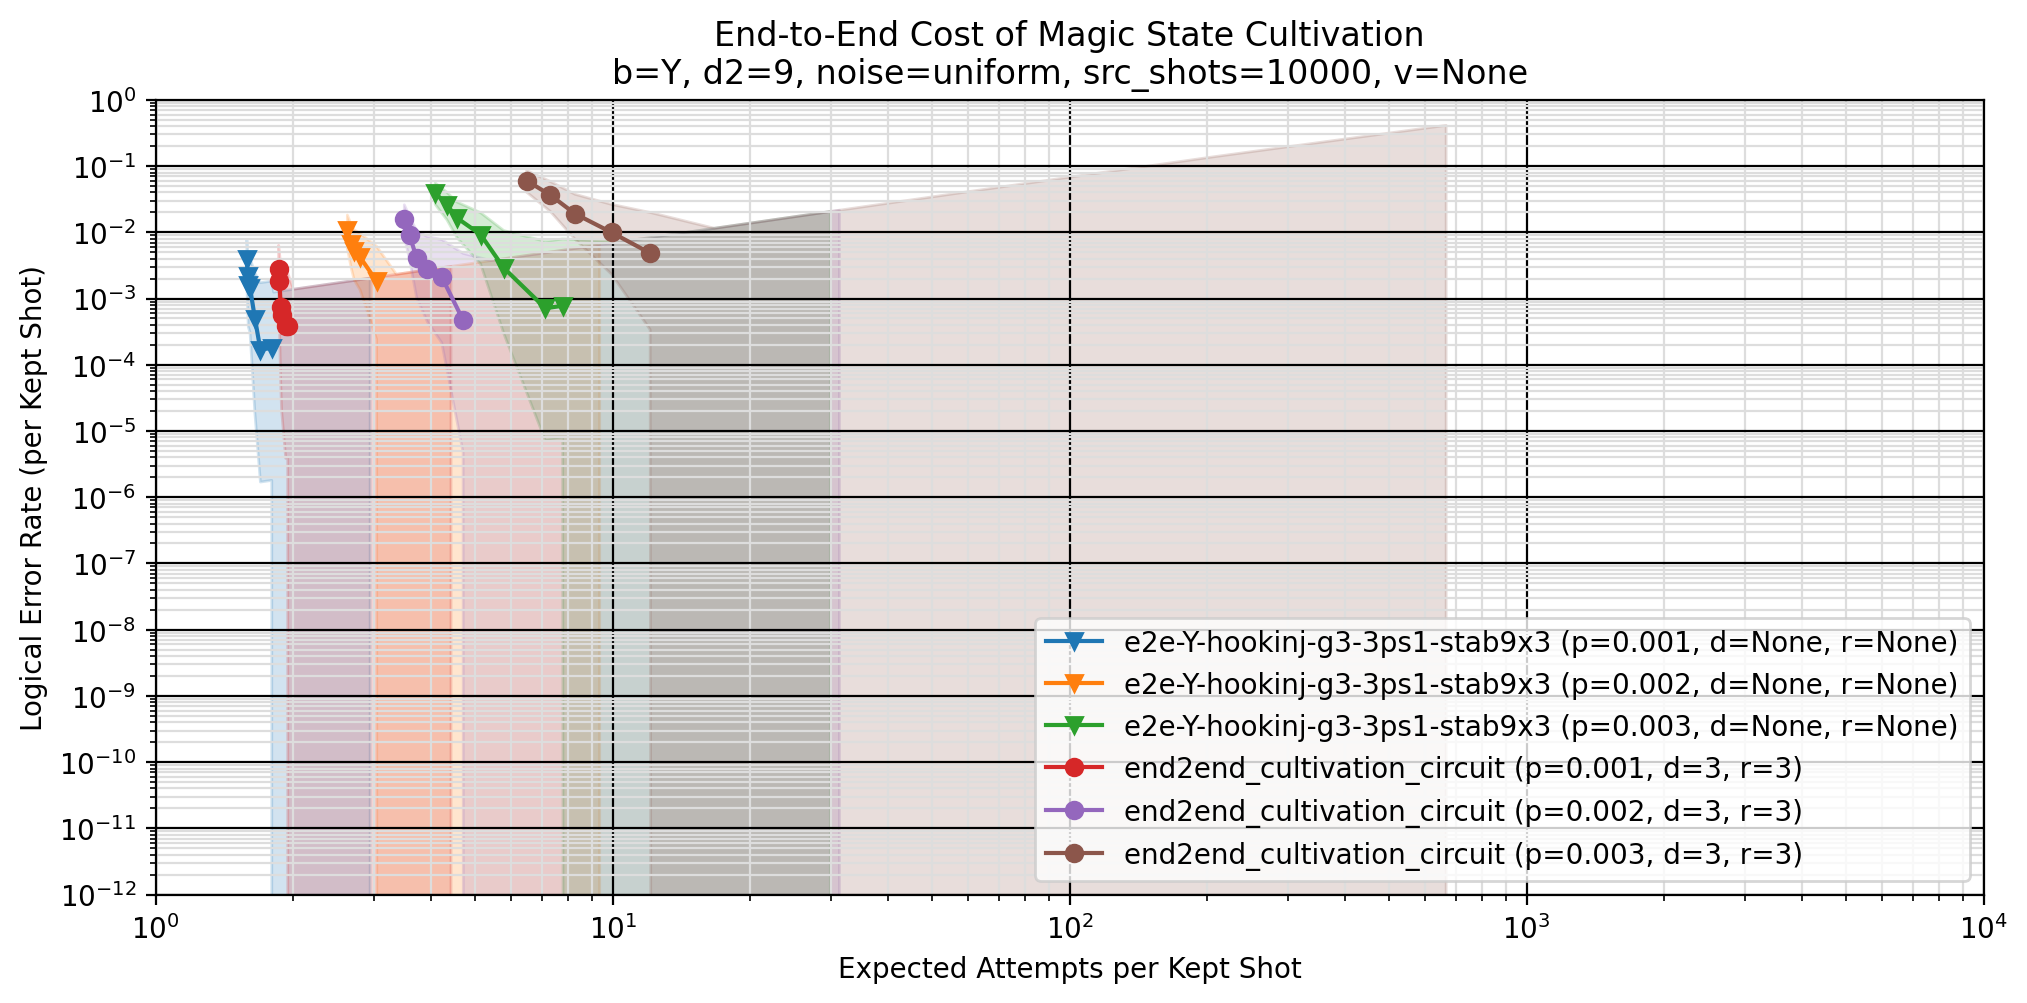

In [63]:
import sys
import pathlib
from sinter._command._main import main

# Define the command-line arguments as a list
command_args = [
    '--in', 'cultivation_outfile_results.csv',
    '--preprocess_stats_func', "__import__('cultiv').split_by_gap_threshold(stats, gap_rounding=5)",
    '--group_func', "{'label': f'''{m.c} (p={m.p}, d={getattr(m, 'd1', getattr(m, 'd2', 'N/A'))}, r={getattr(m, 'r1', getattr(m, 'latter_rounds', 'N/A'))})''', 'marker': 'o' if m.c == 'end2end_cultivation_circuit' else 'v', 'color': f'{m.c}_{m.p}'}",
    '--xaxis', "[log]Expected Attempts per Kept Shot",
    '--yaxis', "[log]Logical Error Rate (per Kept Shot)",
    '--x_func', "(stat.shots + 1) / (stat.shots - stat.discards + 2)",
    '--title', "End-to-End Cost of Magic State Cultivation",
    '--subtitle', "{common}",
    '--filter_func', "m.c == 'e2e-Y-hookinj-g3-3ps1-stab9x3' or m.c == 'end2end_cultivation_circuit'",
    '--xmin', '1e0',
    '--xmax', '1e4',
    '--ymax', '1',
    '--ymin', '1e-12',
    '--fig_size', '2048', '1024',
    '--dpi', '200',
    '--type', 'error_rate',
    '--out', 'cultivation_end2end_plot.png'
]

# Call sinter's main function with 'plot' and the arguments
main(command_line_args=['plot'] + command_args)

# Find and print the output file path
for k in range(len(command_args) - 1):
    if command_args[k] == '--out':
        print(f'wrote file://{pathlib.Path(command_args[k + 1]).absolute()}')
        break